# BehaviorSpace experiment analysis

This notebook analyzes the **reward magnitude and crowding-out** experiment.

The experiment contains seven values of `high-reward-salience`, with 30 stochastic repetitions per value. It examines the trade-off between:

- short-term target-choice uptake during the reward phase;
- intrinsic motivation;
- habit formation;
- persistence after reward withdrawal;
- behavioral retention and withdrawal drop.

> The results describe the behavior of the computational model under its assumptions. They are not empirical estimates of real shoppers.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

CSV_PATH = Path("./experiments/e1-crowding-out/table.csv")

# BehaviorSpace files contain six metadata rows before the header.
df = pd.read_csv(CSV_PATH, skiprows=6)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()


Rows: 210
Columns: 32


,[run number],number-of-shoppers,reward-cycles,reward-duration,withdrawal-duration,low-reward-salience,high-reward-salience,[step],"choice-rate ""control"" ""baseline""","choice-rate ""low-salience"" ""baseline""",...,"mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience""",high-reward-crowding-out-effect,low-reward-persistence-effect,high-reward-withdrawal-drop,low-reward-withdrawal-drop,high-reward-retention-ratio,low-reward-retention-ratio
0,5,1000,1,60,80,0.15,0.45,170,0.376248,0.367067,...,0.635303,0.417216,0.504805,0.461712,0.060491,0.089545,0.226039,0.033271,0.679335,0.938523
1,6,1000,1,60,80,0.15,0.45,170,0.371956,0.368769,...,0.645581,0.418114,0.497297,0.474324,0.075380,0.087317,0.228691,0.041579,0.681585,0.923433
2,8,1000,1,60,80,0.15,0.45,170,0.387924,0.366266,...,0.637187,0.442066,0.496547,0.475526,0.059258,0.074085,0.216091,0.037100,0.694876,0.931808
3,3,1000,1,60,80,0.15,0.45,170,0.391417,0.369770,...,0.631548,0.409132,0.499249,0.462162,0.070909,0.091217,0.222510,0.035485,0.684877,0.934212
4,7,1000,1,60,80,0.15,0.45,170,0.366667,0.371171,...,0.641495,0.411527,0.521321,0.470270,0.075780,0.110052,0.218193,0.026514,0.690002,0.951479


## 1. Data-quality checks

In [3]:
display(df.dtypes.to_frame("dtype"))
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

design_columns = [
    "number-of-shoppers",
    "reward-cycles",
    "reward-duration",
    "withdrawal-duration",
    "low-reward-salience",
    "high-reward-salience",
    "[step]",
]

display(df[design_columns].nunique().to_frame("unique values"))
display(
    df.groupby("high-reward-salience")
      .size()
      .rename("repetitions")
      .to_frame()
)


,dtype
[run number],int64
number-of-shoppers,int64
reward-cycles,int64
reward-duration,int64
withdrawal-duration,int64
low-reward-salience,float64
high-reward-salience,float64
[step],int64
"choice-rate ""control"" ""baseline""",float64
"choice-rate ""low-salience"" ""baseline""",float64


Missing values: 0
Duplicate rows: 0


,unique values
number-of-shoppers,1
reward-cycles,1
reward-duration,1
withdrawal-duration,1
low-reward-salience,1
high-reward-salience,7
[step],1


,repetitions
high-reward-salience,
0.45,30
0.55,30
0.60,30
0.65,30
0.75,30
0.85,30
0.95,30


Expected structure:

- 7 values of `high-reward-salience`;
- 30 repetitions per value;
- 210 rows in total;
- all other experimental parameters fixed.


## 2. Rename key metrics

In [4]:
metric_map = {
    'choice-rate "high-salience" "reward"': "reward_choice_rate",
    'persistence "high-salience"': "persistence",
    'persistence-index "high-salience"': "persistence_index",
    'mean-intrinsic-motivation "high-salience"': "intrinsic_motivation",
    'mean-habit "high-salience"': "habit_strength",
    "high-reward-crowding-out-effect": "motivation_gap_vs_control",
    "high-reward-withdrawal-drop": "withdrawal_drop",
    "high-reward-retention-ratio": "retention_ratio",
}

analysis_df = df.rename(columns=metric_map).copy()
analysis_df[
    ["high-reward-salience"] + list(metric_map.values())
].head()


,high-reward-salience,reward_choice_rate,persistence,persistence_index,intrinsic_motivation,habit_strength,motivation_gap_vs_control,withdrawal_drop,retention_ratio
0,0.45,0.704905,0.478866,0.104992,0.635303,0.461712,0.060491,0.226039,0.679335
1,0.45,0.718218,0.489527,0.104942,0.645581,0.474324,0.075380,0.228691,0.681585
2,0.45,0.708208,0.492117,0.096922,0.637187,0.475526,0.059258,0.216091,0.694876
3,0.45,0.706106,0.483596,0.093906,0.631548,0.462162,0.070909,0.222510,0.684877
4,0.45,0.703854,0.485661,0.114089,0.641495,0.470270,0.075780,0.218193,0.690002


## 3. Descriptive statistics and 95% confidence intervals

In [5]:
KEY_METRICS = list(metric_map.values())

def summarize_with_ci(data, group_col, metrics, confidence=0.95):
    rows = []
    for group_value, group in data.groupby(group_col):
        row = {group_col: group_value, "n": len(group)}
        for metric in metrics:
            values = group[metric].dropna()
            mean = values.mean()
            sd = values.std(ddof=1)
            sem = stats.sem(values)
            low, high = stats.t.interval(
                confidence,
                len(values) - 1,
                loc=mean,
                scale=sem,
            )
            row[f"{metric}_mean"] = mean
            row[f"{metric}_sd"] = sd
            row[f"{metric}_ci_low"] = low
            row[f"{metric}_ci_high"] = high
        rows.append(row)
    return pd.DataFrame(rows).sort_values(group_col)

summary = summarize_with_ci(
    analysis_df,
    "high-reward-salience",
    KEY_METRICS,
)

summary_table = summary[
    [
        "high-reward-salience",
        "n",
        "reward_choice_rate_mean",
        "persistence_mean",
        "persistence_index_mean",
        "intrinsic_motivation_mean",
        "habit_strength_mean",
        "motivation_gap_vs_control_mean",
        "withdrawal_drop_mean",
        "retention_ratio_mean",
    ]
].round(4)

display(summary_table)


,high-reward-salience,n,reward_choice_rate_mean,persistence_mean,persistence_index_mean,intrinsic_motivation_mean,habit_strength_mean,motivation_gap_vs_control_mean,withdrawal_drop_mean,retention_ratio_mean
0,0.45,30,0.7026,0.4860,0.1080,0.6334,0.4692,0.0738,0.2165,0.6918
1,0.55,30,0.7428,0.4598,0.0827,0.5516,0.4388,0.0414,0.2830,0.6190
2,0.60,30,0.7572,0.4414,0.0658,0.5008,0.4159,0.0248,0.3157,0.5830
3,0.65,30,0.7770,0.4335,0.0557,0.4703,0.4059,0.0203,0.3435,0.5579
4,0.75,30,0.8083,0.4196,0.0425,0.4162,0.3909,0.0030,0.3887,0.5191
5,0.85,30,0.8371,0.4025,0.0283,0.3651,0.3696,-0.0136,0.4346,0.4808
6,0.95,30,0.8615,0.3902,0.0132,0.3223,0.3550,-0.0244,0.4713,0.4529


## 4. Main response curves

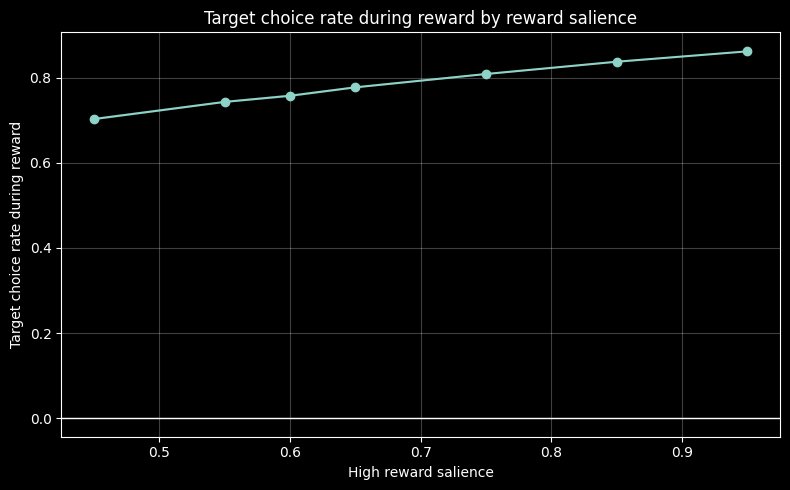

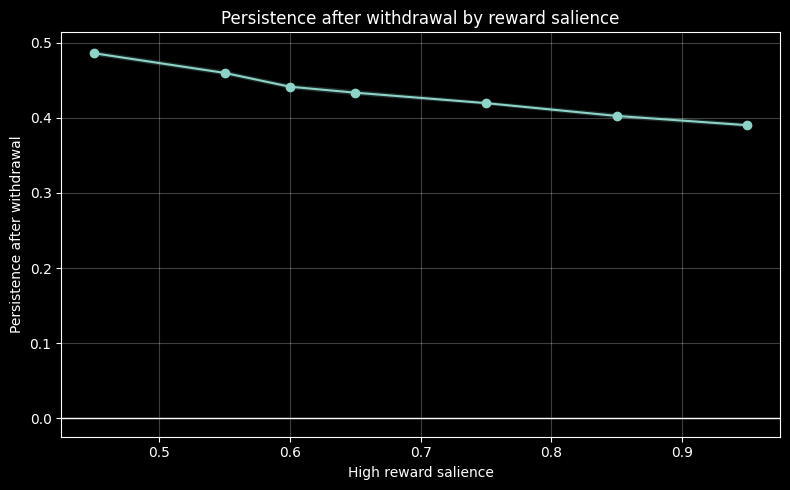

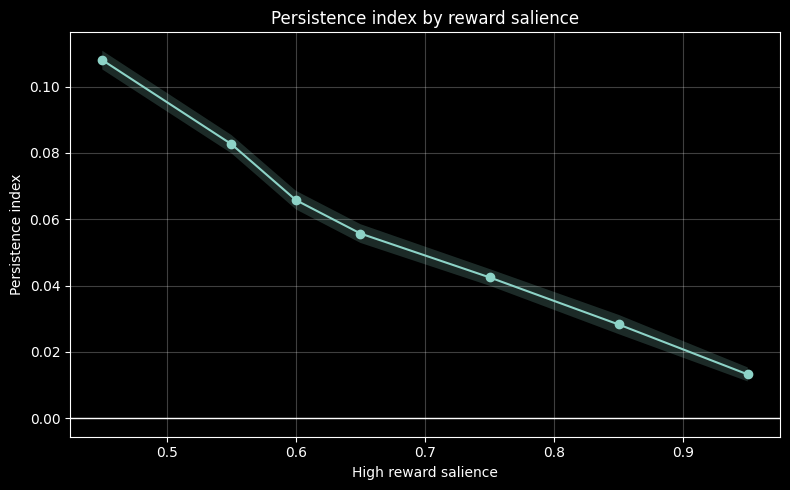

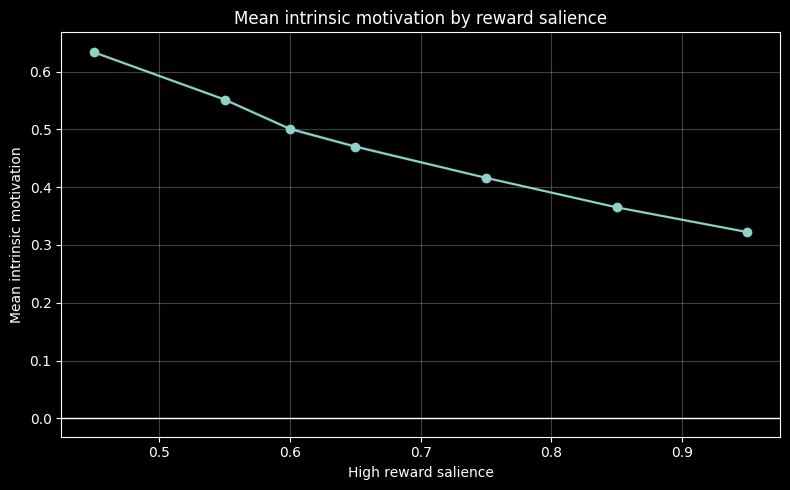

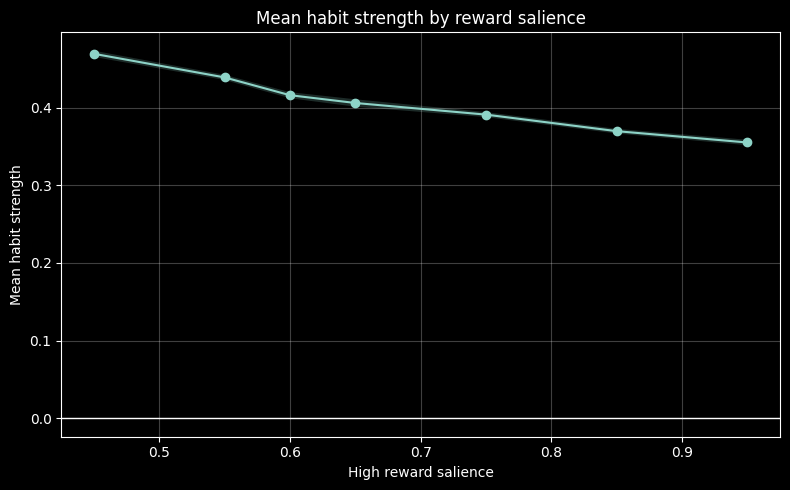

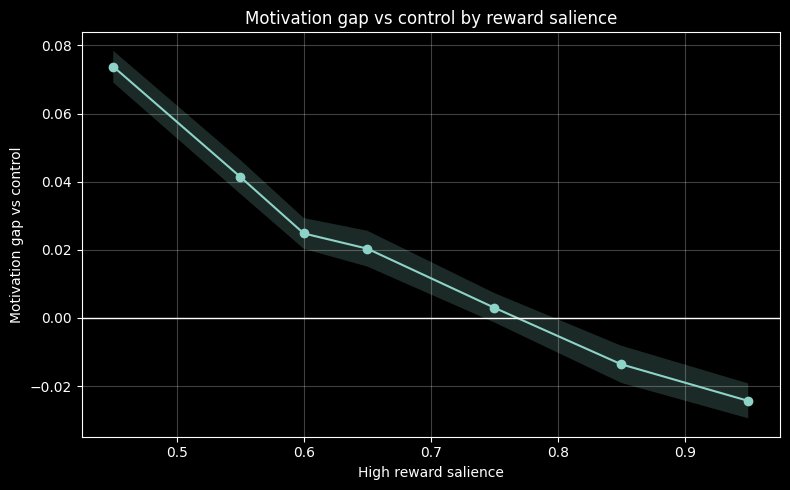

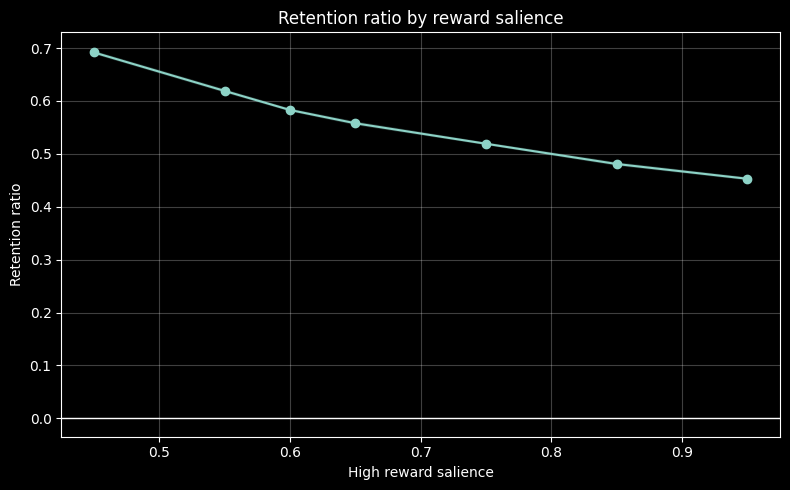

In [6]:
def plot_mean_ci(summary_df, metric, ylabel):
    x = summary_df["high-reward-salience"]
    y = summary_df[f"{metric}_mean"]
    lower = summary_df[f"{metric}_ci_low"]
    upper = summary_df[f"{metric}_ci_high"]

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, marker="o")
    plt.fill_between(x, lower, upper, alpha=0.2)
    plt.axhline(0, linewidth=1)
    plt.xlabel("High reward salience")
    plt.ylabel(ylabel)
    plt.title(ylabel + " by reward salience")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_mean_ci(summary, "reward_choice_rate", "Target choice rate during reward")
plot_mean_ci(summary, "persistence", "Persistence after withdrawal")
plot_mean_ci(summary, "persistence_index", "Persistence index")
plot_mean_ci(summary, "intrinsic_motivation", "Mean intrinsic motivation")
plot_mean_ci(summary, "habit_strength", "Mean habit strength")
plot_mean_ci(summary, "motivation_gap_vs_control", "Motivation gap vs control")
plot_mean_ci(summary, "retention_ratio", "Retention ratio")


### Reading the motivation-gap graph

- Positive values: the rewarded group's mean intrinsic motivation remains above the control group's value.
- Zero: no motivational difference from control.
- Negative values: the rewarded group's intrinsic motivation is below control, which is the model's direct crowding-out signal.


## 5. Statistical tests

In [7]:
test_rows = []

for metric in KEY_METRICS:
    groups = [
        group[metric].dropna().values
        for _, group in analysis_df.groupby("high-reward-salience")
    ]

    f_stat, anova_p = stats.f_oneway(*groups)
    rho, trend_p = stats.spearmanr(
        analysis_df["high-reward-salience"],
        analysis_df[metric],
    )

    test_rows.append(
        {
            "metric": metric,
            "ANOVA F": f_stat,
            "ANOVA p": anova_p,
            "Spearman rho": rho,
            "trend p": trend_p,
        }
    )

tests = pd.DataFrame(test_rows)
display(tests)


,metric,ANOVA F,ANOVA p,Spearman rho,trend p
0,reward_choice_rate,2243.668382,1.439456e-182,0.986537,1.519607e-165
1,persistence,446.855393,4.799415e-114,-0.963008,2.022112e-120
2,persistence_index,604.777289,1.495736e-126,-0.972356,2.285792e-133
3,intrinsic_motivation,6415.045519,1.931780e-228,-0.989597,3.990850e-177
4,habit_strength,467.376695,6.934791e-116,-0.963716,2.809818e-121
5,motivation_gap_vs_control,193.780773,3.623401e-81,-0.913441,3.718562e-83
6,withdrawal_drop,5491.420377,1.256309e-221,0.989755,8.238125e-178
7,retention_ratio,2730.640609,4.157865e-191,-0.987909,2.283093e-170


The one-way ANOVA tests whether at least one salience level differs from the others.  
Spearman's correlation tests the direction and strength of the monotonic trend across salience levels.

Because the observations are simulation repetitions rather than sampled human participants, very small p-values mainly indicate that the model produces stable differences relative to its stochastic noise. Effect sizes and response curves are more substantively important.


## 6. Locate the crowding-out crossover

In [8]:
gap_summary = summary[
    [
        "high-reward-salience",
        "motivation_gap_vs_control_mean",
        "motivation_gap_vs_control_ci_low",
        "motivation_gap_vs_control_ci_high",
    ]
].copy()

display(gap_summary.round(5))

negative_levels = gap_summary.loc[
    gap_summary["motivation_gap_vs_control_mean"] < 0,
    "high-reward-salience",
]

if len(negative_levels):
    first_negative = negative_levels.iloc[0]
    print("First tested level with a negative mean gap:", first_negative)
else:
    print("No tested salience level produced a negative mean gap.")


,high-reward-salience,motivation_gap_vs_control_mean,motivation_gap_vs_control_ci_low,motivation_gap_vs_control_ci_high
0,0.45,0.07379,0.06911,0.07846
1,0.55,0.04143,0.03644,0.04641
2,0.60,0.02481,0.02029,0.02933
3,0.65,0.02034,0.01508,0.02561
4,0.75,0.00301,-0.00131,0.00732
5,0.85,-0.01361,-0.01908,-0.00815
6,0.95,-0.02436,-0.02948,-0.01924


First tested level with a negative mean gap: 0.85


A more precise crossover estimate requires a denser experiment around the sign change.  
For the current results, a useful follow-up grid would be approximately `0.76–0.85` in increments of `0.01`.


## 7. Trade-off between short-term uptake and long-term persistence

,high-reward-salience,reward_choice_rate_mean,persistence_mean,persistence_index_mean,intrinsic_motivation_mean,motivation_gap_vs_control_mean
0,0.45,0.7026,0.4860,0.1080,0.6334,0.0738
1,0.55,0.7428,0.4598,0.0827,0.5516,0.0414
2,0.60,0.7572,0.4414,0.0658,0.5008,0.0248
3,0.65,0.7770,0.4335,0.0557,0.4703,0.0203
4,0.75,0.8083,0.4196,0.0425,0.4162,0.0030
5,0.85,0.8371,0.4025,0.0283,0.3651,-0.0136
6,0.95,0.8615,0.3902,0.0132,0.3223,-0.0244


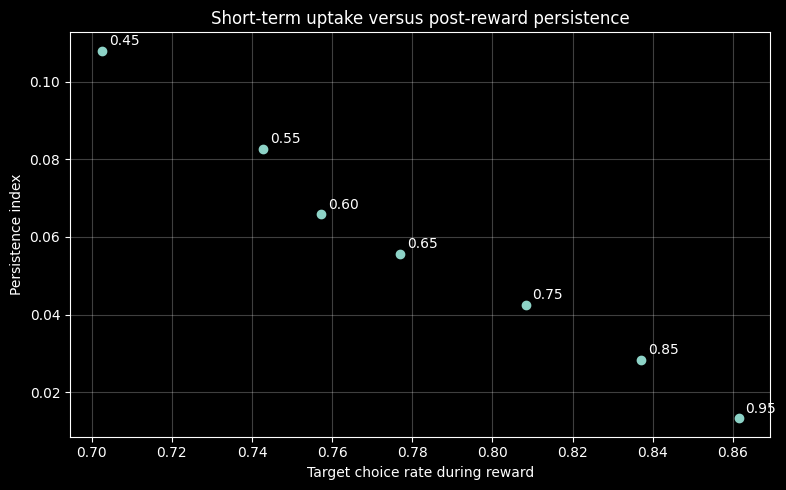

In [9]:
tradeoff = summary[
    [
        "high-reward-salience",
        "reward_choice_rate_mean",
        "persistence_mean",
        "persistence_index_mean",
        "intrinsic_motivation_mean",
        "motivation_gap_vs_control_mean",
    ]
].copy()

display(tradeoff.round(4))

plt.figure(figsize=(8, 5))
plt.scatter(
    tradeoff["reward_choice_rate_mean"],
    tradeoff["persistence_index_mean"],
)
for _, row in tradeoff.iterrows():
    plt.annotate(
        f'{row["high-reward-salience"]:.2f}',
        (row["reward_choice_rate_mean"], row["persistence_index_mean"]),
        xytext=(5, 4),
        textcoords="offset points",
    )
plt.xlabel("Target choice rate during reward")
plt.ylabel("Persistence index")
plt.title("Short-term uptake versus post-reward persistence")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 8. Simple multi-objective score

In [10]:
# Illustrative score only. Change the weights to match the research objective.
# Higher is better:
# - reward uptake
# - persistence index
# - intrinsic motivation
#
# This does not replace a formal BehaviorSearch objective.

score_df = tradeoff.copy()

for col in [
    "reward_choice_rate_mean",
    "persistence_index_mean",
    "intrinsic_motivation_mean",
]:
    min_value = score_df[col].min()
    max_value = score_df[col].max()
    score_df[f"{col}_scaled"] = (
        score_df[col] - min_value
    ) / (max_value - min_value)

score_df["balanced_score"] = (
    0.30 * score_df["reward_choice_rate_mean_scaled"]
    + 0.45 * score_df["persistence_index_mean_scaled"]
    + 0.25 * score_df["intrinsic_motivation_mean_scaled"]
)

display(
    score_df[
        [
            "high-reward-salience",
            "reward_choice_rate_mean",
            "persistence_index_mean",
            "intrinsic_motivation_mean",
            "balanced_score",
        ]
    ].sort_values("balanced_score", ascending=False).round(4)
)


,high-reward-salience,reward_choice_rate_mean,persistence_index_mean,intrinsic_motivation_mean,balanced_score
0,0.45,0.7026,0.1080,0.6334,0.7000
1,0.55,0.7428,0.0827,0.5516,0.5899
2,0.60,0.7572,0.0658,0.5008,0.4961
3,0.65,0.7770,0.0557,0.4703,0.4611
4,0.75,0.8083,0.0425,0.4162,0.4139
5,0.85,0.8371,0.0283,0.3651,0.3599
6,0.95,0.8615,0.0132,0.3223,0.3000


## 9. Main conclusions from the current experiment

1. **Higher rewards increase short-term target choice.** The mean target-choice rate during the reward phase rises monotonically as high reward salience increases.
2. **The short-term gain is accompanied by weaker durability.** Persistence, Persistence Index, and retention ratio all decline as salience increases.
3. **Intrinsic motivation is progressively eroded.** Mean intrinsic motivation falls strongly across the reward grid.
4. **The model produces a crowding-out crossover.** The mean motivation gap versus control becomes negative between the tested values `0.75` and `0.85`.
5. **Higher rewards do not produce stronger end-state habits in this experiment.** Mean habit strength after the full simulation declines with salience, consistent with a larger post-withdrawal behavioral collapse.
6. **There is a clear policy trade-off.** Maximizing uptake during the campaign selects a high reward, whereas maximizing post-program persistence favors a lower reward.
7. **All tested levels still have a positive Persistence Index.** Even the highest tested reward leaves post-withdrawal behavior slightly above baseline on average, so motivational crowding-out does not yet produce a complete behavioral reversal in this experiment.

These conclusions are conditional on the model's update rules, distributions, fixed durations, and current parameter ranges.


## 10. Suggested follow-up experiments

### A. Refine the crowding-out threshold
Test reward levels from about `0.76` to `0.85` in increments of `0.01`, with at least 30–50 repetitions.

### B. Magnitude × duration
Cross reward magnitude with reward duration to determine whether longer exposure builds enough habit to compensate for motivational loss.

### C. Repeated campaign structure
Compare one continuous campaign with several shorter reward cycles separated by withdrawals.

### D. Robustness to shopper heterogeneity
Vary the ranges or distributions of reward sensitivity and autonomy sensitivity.

### E. Multi-objective optimization
Use BehaviorSearch to maximize Persistence Index and target-choice uptake while penalizing negative motivation gap or excessive reward cost.


## 11. Export analysis tables

In [11]:
summary_table.to_csv("behaviorspace_summary.csv", index=False)
tests.to_csv("behaviorspace_statistical_tests.csv", index=False)
tradeoff.to_csv("behaviorspace_tradeoff.csv", index=False)

print("Exported:")
print("- behaviorspace_summary.csv")
print("- behaviorspace_statistical_tests.csv")
print("- behaviorspace_tradeoff.csv")


Exported:
- behaviorspace_summary.csv
- behaviorspace_statistical_tests.csv
- behaviorspace_tradeoff.csv
